# Predicting Conformational Ensemebles with Subsampled AF2

This notebook replicates the methods used to generate the deep MSA for predicting conformational ensembles like the ones described in the "Predicting Relative Populations of Protein Conformations without a Physics Engine Using AlphaFold2" 2023 pre-print (Monteiro da Silva et. al, 10.1101/2023.07.25.550545v1).

Importantly, this notebook does not include a cell for actually running AF2, as collab sessions usually do not have sufficient resources to run AF2 with deep MSAs. We've included the methods for running AF2 as we did at the end of the notebook, complete with code snippets.

This notebook also does not include analysis of the predicted results for the relative state populations or conformational diversity or mechanistic insights, as that is system and goal-dependant. We suggest the usage of PyMol, PyTraj, MDTraj, Chimera, or other structure/trajectory analysis methods for that purpose.

Code snippets were mostly taken with few adaptations from the AlphaFold2_advanced collab notebook from the ColabFold implementation (https://github.com/sokrypton/ColabFold), and all the credits belong to the original authors (Mirdita M, Schütze K, Moriwaki Y, Heo L, Ovchinnikov S and Steinegger M., Jumper et al)

**Important**:
Since Collab now uses Numpy >1.20, the code from the original CollabFold Advanced notebook does not work. Below I have implemented a quick fix that requires running the two cells imediately below, then restarting the kernel, then procceeding as normal.

In [1]:
##@title Install software
#@markdown Please execute this cell by pressing the _Play_ button
#@markdown on the left.

#@markdown Important: if this cells raises an error due to numpy conflicts, run the cell below it and restart the kernel, then re-run.


# setup device
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import sys
import tensorflow as tf
import jax

try:
  # check if TPU is available
  import jax.tools.colab_tpu
  jax.tools.colab_tpu.setup_tpu()
  print('Running on TPU')
  DEVICE = "tpu"
except:
  if jax.local_devices()[0].platform == 'cpu':
    print("WARNING: no GPU detected, will be using CPU")
    DEVICE = "cpu"
  else:
    print('Running on GPU')
    DEVICE = "gpu"
    # disable GPU on tensorflow
    tf.config.set_visible_devices([], 'GPU')

from IPython.utils import io
import subprocess
import tqdm.notebook

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

install_jackhmmer = True
GIT_REPO = 'https://github.com/deepmind/alphafold'
SOURCE_URL = 'https://storage.googleapis.com/alphafold/alphafold_params_2021-07-14.tar'
PARAMS_DIR = './alphafold/data/params'
PARAMS_PATH = os.path.join(PARAMS_DIR, os.path.basename(SOURCE_URL))
TQDM_BAR_FORMAT = '{l_bar}{bar}| {n_fmt}/{total_fmt} [elapsed: {elapsed} remaining: {remaining}]'
TMP_DIR = "tmp"
os.makedirs(TMP_DIR, exist_ok=True)

# if not already installed
total = 55
with tqdm.notebook.tqdm(total=total, bar_format=TQDM_BAR_FORMAT) as pbar:
  if not os.path.isdir("alphafold"):
    # download alphafold code
    os.system(f"git clone {GIT_REPO} alphafold; cd alphafold; git checkout 1d43aaff941c84dc56311076b58795797e49107b")
    os.system(f"git clone https://github.com/sokrypton/ColabFold.git")

    # apply patches
    os.system(f"patch -u alphafold/alphafold/model/model.py -i ColabFold/beta/model.patch")
    os.system(f"patch -u alphafold/alphafold/model/mapping.py -i ColabFold/beta/mapping.patch")
    os.system(f"patch -u alphafold/alphafold/model/modules.py -i ColabFold/beta/modules.patch")
    os.system(f"patch -u alphafold/alphafold/model/folding.py -i ColabFold/beta/folding.patch")
    os.system(f"patch -u alphafold/alphafold/model/config.py -i ColabFold/beta/config.patch")
    # apply multi-chain patch from Lim Heo @huhlim
    os.system(f"patch -u alphafold/alphafold/common/protein.py -i ColabFold/beta/protein.patch")
    pbar.update(4)

    os.system(f"pip install biopython dm-haiku==0.0.9 ml-collections py3Dmol")
    pbar.update(6)

    # download model params (speedup from kaczmarj)
    os.system(f"mkdir --parents {PARAMS_DIR}")
    os.system(f"curl -fsSL {SOURCE_URL} | tar x -C {PARAMS_DIR}")
    pbar.update(14+27)

    # install hhsuite
    os.system(f"curl -fsSL https://github.com/soedinglab/hh-suite/releases/download/v3.3.0/hhsuite-3.3.0-SSE2-Linux.tar.gz | tar xz -C {TMP_DIR}/")

    # install jackhmmer
    if install_jackhmmer:
      os.system(f"sudo apt install --quiet --yes hmmer")
      pbar.update(3)

      # create a ramdisk to store a database chunk to make Jackhmmer run fast.
      os.system(f"sudo mkdir -m 777 --parents /tmp/ramdisk")
      os.system(f"sudo mount -t tmpfs -o size=9G ramdisk /tmp/ramdisk")
      pbar.update(1)

    else:
      pbar.update(4)

  else:
    pbar.update(55)

########################################################################################
# --- Python imports ---
if 'alphafold' not in sys.path:
  sys.path.append('alphafold')
if 'ColabFold/beta' not in sys.path:
  sys.path.append('ColabFold/beta')

if f"{TMP_DIR}/bin" not in os.environ['PATH']:
  os.environ['PATH'] += f":{TMP_DIR}/bin:{TMP_DIR}/scripts"

import os
import re

def replace_np_int(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.py'):
                filepath = os.path.join(root, file)

                try:
                    with open(filepath, 'r', encoding='utf-8') as f:
                        content = f.read()
                except UnicodeDecodeError:
                    try:
                        with open(filepath, 'r', encoding='ISO-8859-1') as f:
                            content = f.read()
                    except UnicodeDecodeError:
                        print(f"Skipping file due to encoding issue: {filepath}")
                        continue

                # Replace 'np.int' with 'int'
                updated_content, num_replacements = re.subn(r'\bnp\.int\b', 'int', content)

                if num_replacements > 0:
                    # Write the changes back to the file
                    with open(filepath, 'w', encoding='utf-8') as f:
                        f.write(updated_content)
                    print(f"Updated {num_replacements} occurrences in: {filepath}")

# Replace 'your_directory_path' with the path to your target directory
# replace_np_int('/.')


import colabfold as cf
import colabfold_alphafold as cf_af

import json
import matplotlib.pyplot as plt
import numpy as np

try:
  from google.colab import files
  IN_COLAB = True
except:
  IN_COLAB = False

  0%|          | 0/55 [elapsed: 00:00 remaining: ?]

AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [ ]:

#@markdown Important: Only run this cell if the cell above raised an error
#@markdown Please execute this cell by pressing the _Play_ button due to numpy version mismatches, otherwise skip it.
#@markdown After running, restart the kernel, re-run the cell above, and skip this cell.
import os
import re

def replace_np_class(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.py'):
                filepath = os.path.join(root, file)
                try:
                    with open(filepath, 'r', encoding='utf-8') as f:
                        content = f.read()
                except UnicodeDecodeError:
                    try:
                        with open(filepath, 'r', encoding='iso-8859-1') as f:
                            content = f.read()
                    except UnicodeDecodeError:
                        print(f"Could not read {filepath} due to encoding issues.")
                        continue

                # Replace 'np.class' with 'class'
                updated_content = re.sub(r'\bnp\.int\b', 'int', content)

                if content != updated_content:
                    try:
                        with open(filepath, 'w', encoding='utf-8') as f:
                            f.write(updated_content)
                        print(f"Updated {filepath}")
                    except UnicodeEncodeError:
                        print(f"Could not write to {filepath} due to encoding issues.")

# Replace 'your_directory_path' with the path to your directory
replace_np_class('/content')

def replace_np_class(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.py'):
                filepath = os.path.join(root, file)
                try:
                    with open(filepath, 'r', encoding='utf-8') as f:
                        content = f.read()
                except UnicodeDecodeError:
                    try:
                        with open(filepath, 'r', encoding='iso-8859-1') as f:
                            content = f.read()
                    except UnicodeDecodeError:
                        print(f"Could not read {filepath} due to encoding issues.")
                        continue

                # Replace 'np.class' with 'class'
                updated_content = re.sub(r'\bnp\.object\b', 'object', content)

                if content != updated_content:
                    try:
                        with open(filepath, 'w', encoding='utf-8') as f:
                            f.write(updated_content)
                        print(f"Updated {filepath}")
                    except UnicodeEncodeError:
                        print(f"Could not write to {filepath} due to encoding issues.")

# Replace 'your_directory_path' with the path to your directory
replace_np_class('/content')
!pip install biopython==1.81

!pip install --upgrade "jax[cuda11_pip]==0.4.23" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html


Updated /content/alphafold/alphafold/common/residue_constants.py
Updated /content/alphafold/alphafold/data/templates.py
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.2 MB/s eta 0:00:00
  Attempting uninstall: biopython
    Found existing installation: biopython 1.85
    Uninstalling biopython-1.85:
      Successfully uninstalled biopython-1.85
Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.5/434.5 MB 4.5 MB/s eta 0:00:00


Mounted at /content/gdrive
homooligomer: 1
total_length: 717
output_dir: prediction_hMDA5_3091025_L372R_7ab9e
running jackhmmer on seq_0


  0%|          | 0/147 [elapsed: 00:00 remaining: ?]

15545 Sequences Found in uniref90
1014 Sequences Found in smallbfd
499 Sequences Found in mgnify


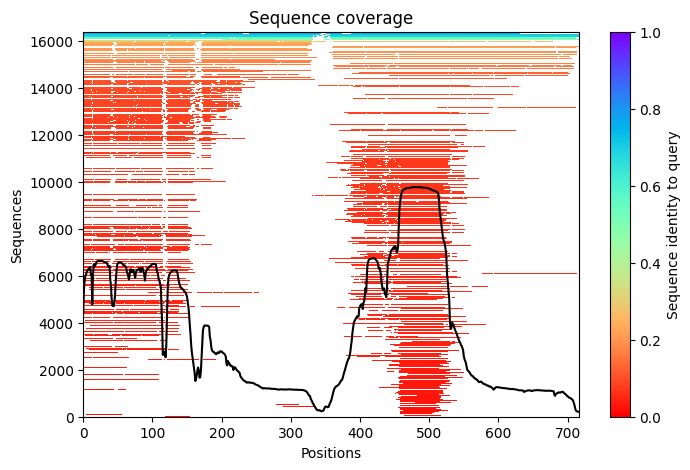

homooligomer: 1
total_length: 717
output_dir: prediction_hMDA5_3091025_G389R_30b93
running jackhmmer on seq_0


  0%|          | 0/147 [elapsed: 00:00 remaining: ?]

15767 Sequences Found in uniref90
1030 Sequences Found in smallbfd
499 Sequences Found in mgnify


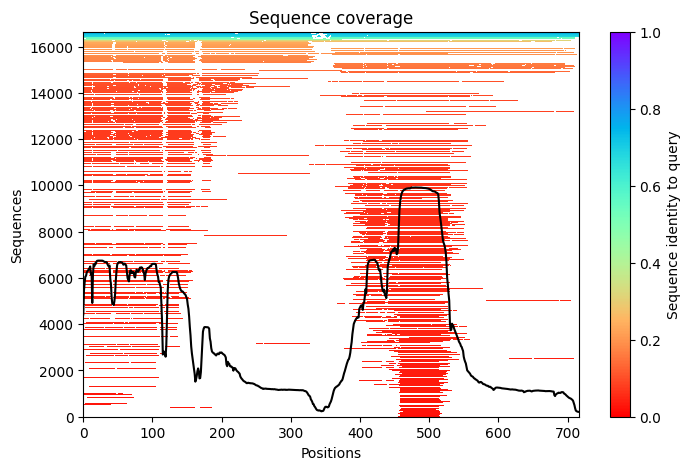

homooligomer: 1
total_length: 717
output_dir: prediction_hMDA5_3091025_D393A_df99a
running jackhmmer on seq_0


  0%|          | 0/147 [elapsed: 00:00 remaining: ?]

16084 Sequences Found in uniref90
1039 Sequences Found in smallbfd
500 Sequences Found in mgnify


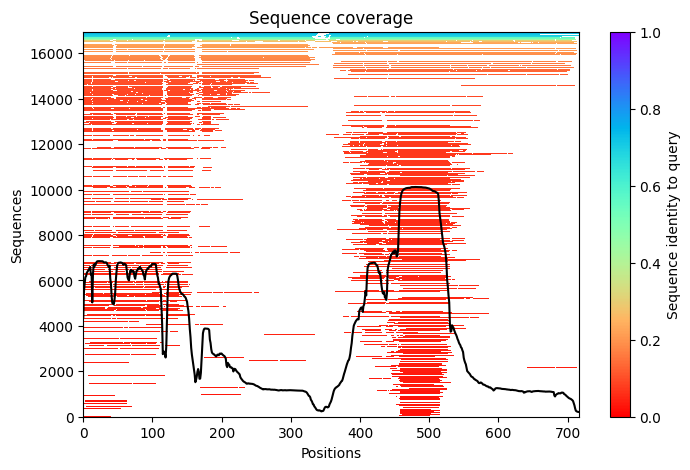

homooligomer: 1
total_length: 717
output_dir: prediction_hMDA5_3091025_D393V_87fc8
running jackhmmer on seq_0


  0%|          | 0/147 [elapsed: 00:00 remaining: ?]

In [ ]:
#@title Search against genetic databases
#@markdown Once this cell has been executed, you will see
#@markdown statistics about the multiple sequence alignment
#@markdown (MSA) that will be used by AlphaFold. In particular,
#@markdown you’ll see how well each residue is covered by similar
#@markdown sequences in the MSA.
#@markdown (Note that the search against databases and the actual prediction can take some time, from minutes to hours, depending on the length of the protein and what type of GPU you are allocated by Colab.)

from google.colab import drive
import ast
drive.mount('/content/gdrive')

def reformat_sequences(input_array):
    formatted_sequences = []
    for idx, sequence in enumerate(input_array[0]):
        formatted_sequence = f">sequence_{idx + 1}\n{sequence}\n"
        formatted_sequences.append(formatted_sequence)
    return formatted_sequences



def save_formatted_sequences_to_file(formatted_sequences, output_file):
    with open(f'/content/gdrive/My Drive/{output_file}', 'w') as f:
        for sequence in formatted_sequences:
            f.write(sequence)

sequence_dict = {'hMDA5_309-1025_L372R': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQRFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_G389R': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIRLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_D393A': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGATQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_D393V': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGVTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_I416L': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQLLENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_D443G': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIGECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_E444G': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDGCHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_N449K': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTKKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_A452T': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKETVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_A489T': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTTSPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_A489S': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTSSPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_I583V': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAVQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_I617T': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTTRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_A719V': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESVRGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_R720Q': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESAQGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_E773Q': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKQVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_R779H': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFHTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_R779C': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFCTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_R779L': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFLTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_G781E': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTEKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_N802D': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECDIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_I803F': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNFVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_E813D': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNDIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_G821S': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARSRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_R822Q': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGQARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_R822P': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGPARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_R824K': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRAKADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_R824S': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRASADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_T829S': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESSYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_D848E': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNEFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_A946T': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKTLQKKCADYQINGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_I956V': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQVNGEIICKCGQAWGTMMVHKGLDLPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED',
 'hMDA5_309-1025_L979W': 'RPYQMEVAQPALEGKNIIICLPTGSGKTRVAVYIAKDHLDKKKKASEPGKVIVLVNKVLLVEQLFRKEFQPFLKKWYRVIGLSGDTQLKISFPEVVKSCDIIISTAQILENSLLNLENGEDAGVQLSDFSLIIIDECHHTNKEAVYNNIMRHYLMQKLKNNRLKKENKPVIPLPQILGLTASPGVGGATKQAKAEEHILKLCANLDAFTIKTVKENLDQLKNQIQEPCKKFAIADATREDPFKEKLLEIMTRIQTYCQMSPMSDFGTQPYEQWAIQMEKKAAKEGNRKERVCAEHLRKYNEALQINDTIRMIDAYTHLETFYNEEKDKKFAVIEDDSDEGGDDEYCDGDEDEDDLKKPLKLDETDRFLMTLFFENNKMLKRLAENPEYENEKLTKLRNTIMEQYTRTEESARGIIFTKTRQSAYALSQWITENEKFAEVGVKAHHLIGAGHSSEFKPMTQNEQKEVISKFRTGKINLLIATTVAEEGLDIKECNIVIRYGLVTNEIAMVQARGRARADESTYVLVAHSGSGVIEHETVNDFREKMMYKAIHCVQNMKPEEYAHKILELQMQSIMEKKMKTKRNIAKHYKNNPSLITFLCKNCSVLACSGEDIHVIEKMHHVNMTPEFKELYIVRENKALQKKCADYQINGEIICKCGQAWGTMMVHKGLDWPCLKIRNFVVVFKNNSTKKQYKKWVELPITFPNLDYSECCLFSDED'}

#@markdown ---
msa_method = "jackhmmer" # @param ["jackhmmer", "mmseqs2"]
#@markdown - `mmseqs2` - FAST method from [ColabFold](https://github.com/sokrypton/ColabFold) NOT RECOMMENDED FOR PREDICTING ENSEMBLES as output MSAs are usually shallow compared to JackHMMR
#@markdown - `jackhmmer` - default method from Deepmind (SLOW, usually finds more sequences)
#@markdown you can skip this step by uploading
#@markdown the previously generated  `prediction_?????/msa.pickle`


add_custom_msa = False
msa_format = "fas"
pair_mode = "unpaired"
pair_cov = 50
pair_qid = 20
# --- Search against genetic databases ---

for jobname, sequence in sequence_dict.items():

  homooligomer =  "1"
  I = cf_af.prep_inputs(sequence, jobname, homooligomer, clean=IN_COLAB)
  I = cf_af.prep_msa(I, msa_method, add_custom_msa, msa_format,
                   pair_mode, pair_cov, pair_qid, TMP_DIR=TMP_DIR)
  mod_I = I

  if len(I["msas"][0]) > 1:
    plt = cf.plot_msas(I["msas"], I["ori_sequence"])
    plt.savefig(os.path.join(I["output_dir"],"msa_coverage.png"), bbox_inches = 'tight', dpi=200)
    plt.show()

  original_array = I['msas']
  formatted_sequences = reformat_sequences(original_array)
  output_msa_name = jobname
  output_file = output_msa_name + '.a3m'
  save_formatted_sequences_to_file(formatted_sequences, output_file)

In [ ]:
for i in feature_dict:
  print(i)

aatype
between_segment_residues
domain_name
residue_index
seq_length
sequence
deletion_matrix_int
msa
num_alignments
template_aatype
template_all_atom_masks
template_all_atom_positions
template_domain_names
template_sum_probs
Ls
output_dir


In [ ]:
#@title Run alphafold
num_relax = "None"
rank_by = "pLDDT" #@param ["pLDDT","pTMscore"]
use_turbo = True #@param {type:"boolean"}
max_msa = "32:64" #@param ["512:1024", "256:512", "128:256", "64:128", "32:64"]
max_msa_clusters, max_extra_msa = [int(x) for x in max_msa.split(":")]

#@markdown - `rank_by` specify metric to use for ranking models (For protein-protein complexes, we recommend pTMscore)
#@markdown - `use_turbo` introduces a few modifications (compile once, swap params, adjust max_msa) to speedup and reduce memory requirements. Disable for default behavior.
#@markdown - `max_msa` defines: `max_msa_clusters:max_extra_msa` number of sequences to use. When adjusting after GPU crash, be sure to `Runtime` → `Restart runtime`. (Lowering will reduce GPU requirements, but may result in poor model quality. This option ignored if `use_turbo` is disabled)
show_images = True #@param {type:"boolean"}
#@markdown - `show_images` To make things more exciting we show images of the predicted structures as they are being generated. (WARNING: the order of images displayed does not reflect any ranking).

#@markdown ---
#@markdown **sampling options**

#@markdown There are two stochastic parts of the pipeline. Within the feature generation (choice of cluster centers) and within the model (dropout).
#@markdown To get structure diversity, you can iterate through a fixed number of random_seeds (using `num_samples`) and/or enable dropout (using `is_training`).

num_models = 5 #@param [1,2,3,4,5] {type:"raw"}
use_ptm = True #@param {type:"boolean"}
num_ensemble = 1 #@param [1,2,4,8] {type:"raw"}
max_recycles = 3 #@param [0,1,3,6,12,24,48] {type:"raw"}
is_training = True #@param {type:"boolean"}
num_samples = 32 #@param [1,2,4,8,16,32] {type:"raw"}
#@markdown - `num_models` specify how many model params to try. (5 recommended)
#@markdown - `use_ptm` uses Deepmind's `ptm` finetuned model parameters to get PAE per structure. Disable to use the original model params. (Disabling may give alternative structures.)
#@markdown - `num_ensemble` the trunk of the network is run multiple times with different random choices for the MSA cluster centers. (`1`=`default`, `8`=`casp14 setting`)
#@markdown - `max_recycles` controls the maximum number of times the structure is fed back into the neural network for refinement. (3 recommended)
#@markdown - `is_training` enables the stochastic part of the model (dropout), when coupled with `num_samples` can be used to "sample" a diverse set of structures.
#@markdown - `num_samples` number of random_seeds to try.
subsample_msa = True #@param {type:"boolean"}
#@markdown - `subsample_msa` subsample large MSA to `3E7/length` sequences to avoid crashing the preprocessing protocol. (This option ignored if `use_turbo` is disabled.)

if not use_ptm and rank_by == "pTMscore":
  print("WARNING: models will be ranked by pLDDT, 'use_ptm' is needed to compute pTMscore")
  rank_by = "pLDDT"

# prep input features
feature_dict = cf_af.prep_feats(mod_I, clean=IN_COLAB)
Ls_plot = feature_dict["Ls"]

# prep model options
opt = {"N":len(feature_dict["msa"]),
       "L":len(feature_dict["residue_index"]),
       "use_ptm":use_ptm,
       "use_turbo":use_turbo,
       "max_recycles":max_recycles,
       "tol":0.0,
       "num_ensemble":num_ensemble,
       "max_msa_clusters":max_msa_clusters,
       "max_extra_msa":max_extra_msa,
       "is_training":is_training}

if use_turbo:
  if "runner" in dir():
    # only recompile if options changed
    runner = cf_af.prep_model_runner(opt, old_runner=runner)
  else:
    runner = cf_af.prep_model_runner(opt)
else:
  runner = None

###########################
# run alphafold
###########################
outs, model_rank = cf_af.run_alphafold(feature_dict, opt, runner, num_models, num_samples, subsample_msa,
                                       rank_by=rank_by, show_images=show_images)


AttributeError: module 'jax' has no attribute 'xla'

In [ ]:
feature_dict

{'aatype': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32),
 'between_segment_residues': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0], dtype=int32),
 'domain_name': array([b'test'], dtype=object),
 'residue_index': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44, 

In [ ]:
#@title Instructions for running AF2
# @markdown To make predictions, we've used localcolabfold (https://github.com/YoshitakaMo/localcolabfold) installed in an HPC. To use the large MSAs generated from JackHMMR a lot of RAM is needed (128GB+ for Abl1 with 600k+ sequences deep MSAs).

# @markdown When making predictions for a new system, we usually seek to optimize the `max-seq:max-extra-seq` parameters to maximize the diversity of results (see Figure S1 and S2 on the preprint for more information of what these parameters do and how they affect predictions for an example system).
# @markdown
# @markdown Parameter `max-seq` seems to be the most important of the pair for maximizing diversity.

# @markdown We usually do that by systematically running AF2 with 32+ seeds with different`max-seq:max-extra-seq` parameters and analyzing the distribution of relevant observables among the results using Pymol or PyTraj or VMD or mdtraj or whatever analysis method you prefer.

# @markdown Below is the command we used to generate one of the Wild-Type Abl1 ensembles described in the pre-print.

# @markdown `colabfold_batch --num-seeds 32 --max-msa 256:512 --use-dropout --random-seed 1 abl1_wt.a3m  /output_ablwt_dropout_256512_32_1`

# @markdown This should generate 160 .pdb files (32 seeds * 5 models).

# @markdown `--use-dropout` is so AF2 will learn from the uncertainty of the results when predicting with multiple seeds.

# @markdown Other relevant parameters are the number of recycles (`--num-recycles`, left as default in the example above) and the starting seed in case you're running replicates (`--random-seed` sets the first seed at that number, then it increments it by one for each seed in `--num-seeds`). Decreasing the number of recycles seems to increase the conformational diversity of the ensemble, which makes sense since the MSA is resampled at every recycle.